# **Bibliotecas**

In [ ]:
# Instalações Necessárias
!pip install pydicom # Imagens médicas
!pip install rawpy # Leitura de RAW

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.4 MB/s eta 0:00:00


In [ ]:
# Bibliotecas Padrão
import os
import math
from pathlib import Path

# Númericas
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Manipulação de Imagens
import cv2
from PIL import Image

# DICOM
import pydicom

# RAW
import rawpy

# Sklearn
from sklearn import datasets



* **Numpy** → Operações Matriciais e Quantização
* **Matplotlib** → Visualização e Comparação
* **OpenCV (cv2)** → Conversões RGB/HSV, Redimensionamento
* **PIL** → Leitura e Salvamento JPEG/PNG/TIFF
* **Pydicom** → Leitura de imagens médicas .dcm
* **Rawpy** → Leitura de imagens RAW
* **Sklearn.datasets** → Imagens prontas para experimentos rápidos




# **Aquisição de Imagens**

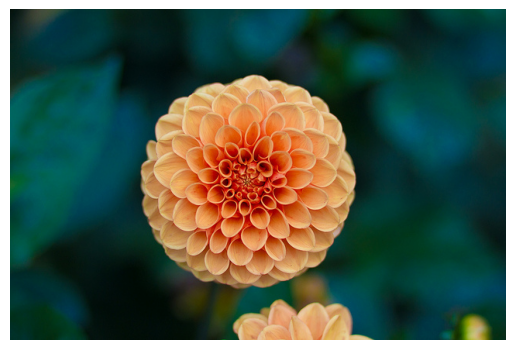

(427, 640, 3)

In [ ]:
# Carregar um imagem scikit-learn
img = datasets.load_sample_image("flower.jpg")

# Exibir a imagem
plt.imshow(img)
plt.axis('off') # Ocultar os eixos (números)
plt.show()

# Tamanho da imagem (altura, largura, número de canais de cor)
img.shape

In [ ]:
# Estatísticas de cores de uma imagem
channel_names = ["R", "G", "B"]
for i, name in enumerate(channel_names):
  ch = img[..., i] # ou img[:, :, i]
  print(f"Canal {name}: min={ch.min():.2f}, max={ch.max():.2f}, media={ch.mean():.2f}, desvio={ch.std():.2f}")

Canal R: min=0.00, max=255.00, media=55.13, desvio=89.02
Canal G: min=0.00, max=229.00, media=73.58, desvio=45.51
Canal B: min=0.00, max=197.00, media=57.00, desvio=33.23


* **img[..., i]:** Em imagens (Matrizes 3D), os dados são organizados como **(Altura, Largura, Canais)**. O **`...`** diz ao NumPy: "mantenha toda a altura e largura, mas pegue apenas o canal **`i`**".

In [ ]:
from pydicom.data import get_testdata_file

filename = get_testdata_file('CT_small.dcm')
dcm = pydicom.dcmread(filename) # Lê o arquivo DICOM completo (metadados + imagem)

img = dcm.pixel_array # Extrai os dados brutos dos pixels como uma matriz NumPy
img_min = np.min(img)
img_max = np.max(img)

print("Dados Reais (Matriz)\n")
print("Shape:", img.shape)
print("Dtype:", img.dtype)
print("Min:", img_min, "| Max:", img_max)
print("Níveis Únicos de Amostras:", np.unique(img).size)

Dados Reais (Matriz)

Shape: (128, 128)
Dtype: int16
Min: 128 | Max: 2191
Níveis Únicos de Amostras: 1453


* **int16 vs uint8:** Enquanto imagens comuns (como JPEGs) usam 8 bits (0 a 255), imagens médicas usam 16 bits. Isso é necessário para capturar diferenças sutis de densidade nos tecidos do corpo humano.

* **np.unique(img).size:** Esse valor (1453) mostra a riqueza de detalhes. Em uma imagem comum, o máximo de níveis únicos seria 256. Aqui, você tem mais de mil variações de intensidade.

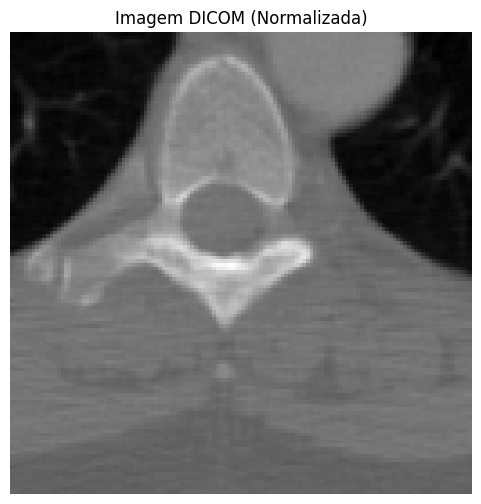

In [ ]:
# Converte os dados (float)
# Isso evita erros de arredondamento e permite divisões decimais na normalização
img = dcm.pixel_array.astype(float)

# Normalização Min-Max
img_norm = (img - img_min) / (img_max - img_min)

plt.figure(figsize=(6, 6))
plt.imshow(img_norm, cmap='gray')
plt.title('Imagem DICOM (Normalizada)')
plt.axis('off')
plt.show()

# **Amostragem / Resolução - Visualizando Aliasing**

In [ ]:
img = datasets.load_sample_image("flower.jpg") #uint8 RGB
H, W = img.shape[:2]

print("Imagem Original\n")
print("Shape:", img.shape)
print("Dtype:", img.dtype)

Imagem Original

Shape: (427, 640, 3)
Dtype: uint8


In [ ]:
# Aliasing (serrilhado)
def aliasing(rgb, scale, down_interp, up_interp):
  # Reduz e amplia para (H,W) mantendo tamanho de vizualização
  new_w = max(1, int(W * scale)) # 1 pixel de tamanho
  new_h = max(1, int(H * scale))
  small = cv2.resize(rgb, (new_w, new_h), interpolation=down_interp) # Downsampling
  back = cv2.resize(small, (W, H), interpolation=up_interp) # Upsampling
  return small, back

scales = [0.5, 0.25, 0.125] # Redução da resolução (50%, 25% e 12.5%)
nearest_results = []
nearest_titles = []
for s in scales: # (Nearest Neighbor)
  small, back = aliasing(img, s, down_interp=cv2.INTER_NEAREST, up_interp=cv2.INTER_NEAREST)
  nearest_results.append(back)
  nearest_titles.append(f"Redução: {int(s*100)}%")

* **Downsampling (`small`):** Você está descartando informações. Ao reduzir para 12.5%, você está tentando representar a imagem original com apenas 1/64 dos pixels totais.

* **Aliasing:** Como você usou **`cv2.INTER_NEAREST`**, o OpenCV não tenta calcular uma média entre os pixels; ele simplesmente escolhe o vizinho mais próximo. Isso cria o efeito de "escada" em bordas diagonais.

* **Upsampling (`back`):** Note que, embora a imagem volte ao tamanho **`(W, H)`**, a informação perdida na redução não retorna. A imagem apenas parecerá mais **"pixelizada"**.

**Observação:** Rodar o mesmo loop trocando a interpolação para **`cv2.INTER_CUBIC`** ou **`cv2.INTER_LINEAR`** fará com que a imagem fique "embaçada" (**blurred**) em vez de **"pixelizada"**.

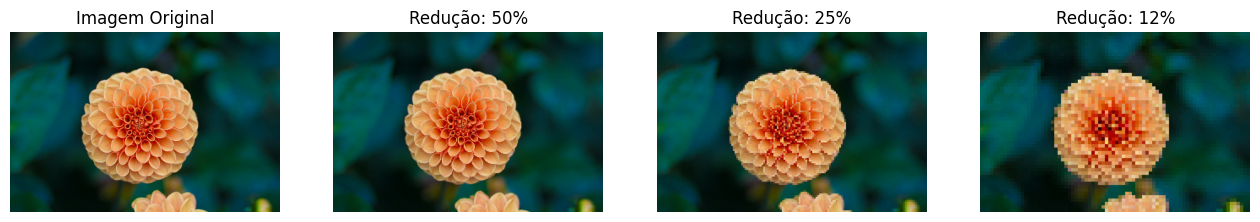

In [ ]:
# Visualização lado a lado
rows = 2
cols = 1 + len(scales)

plt.figure(figsize=(4*cols, 4*rows))

ax = plt.subplot(rows, cols, 1)
ax.imshow(img)
ax.set_title("Imagem Original")
ax.axis('off')

for i, (im, t) in enumerate(zip(nearest_results, nearest_titles), start=2):
  ax = plt.subplot(rows, cols, i)
  ax.imshow(im)
  ax.set_title(t)
  ax.axis('off')

* **`plt.subplot(rows, cols, i)`:** É o que permite colocar várias imagens em uma única janela. O índice **`i`** determina a posição da esquerda para a direita, de cima para baixo.

# **Quantização**

In [ ]:
def quantize_grayscale(img_gray: np.ndarray, levels: int) -> np.ndarray:
    """
    Quantiza uma imagem em escala de cinza para um número específico de tons.
    """

    if levels < 2 or levels > 256:
        raise ValueError("levels deve estar entre 2 e 256")
    if (levels & (levels - 1)) != 0:
        raise ValueError("levels deve ser potência de 2 (2,4,8,...,256)")

    # Mapeia 0...255 -> 0...(levels-1), com arredondamento para o nível mais próximo
    idx = np.round(img_gray.astype(np.float32) * (levels - 1) / 255.0).astype(np.int32)

    # Reconstrói para 0...255 em níveis uniformes
    out = np.round(idx * 255.0 / (levels - 1)).astype(np.uint8)
    return out

def count_unique_levels(img_gray: np.ndarray) -> int:
    return np.unique(img_gray).size # Conta quantos tons de cinza distintos existem na imagem resultante

def plot_quantization_grid(img_gray: np.ndarray, levels_list=(64,32,2), title_prefix=""):
    # Define a quantidade de subplots baseada no tamanho da lista de níveis
    n = len(levels_list)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4), constrained_layout=True)

    # Itera sobre cada eixo (subplot) e cada nível desejado simultaneamente
    for ax, L in zip(axes, levels_list):
        q = quantize_grayscale(img_gray, L)
        unique = count_unique_levels(q)
        ax.imshow(q, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
        ax.set_title(f"{L} níveis\n(usados: {unique})")

    # Se um prefixo for fornecido, adiciona um título principal à figura inteira
    if title_prefix:
        fig.suptitle(title_prefix, fontsize=14)
    plt.show()


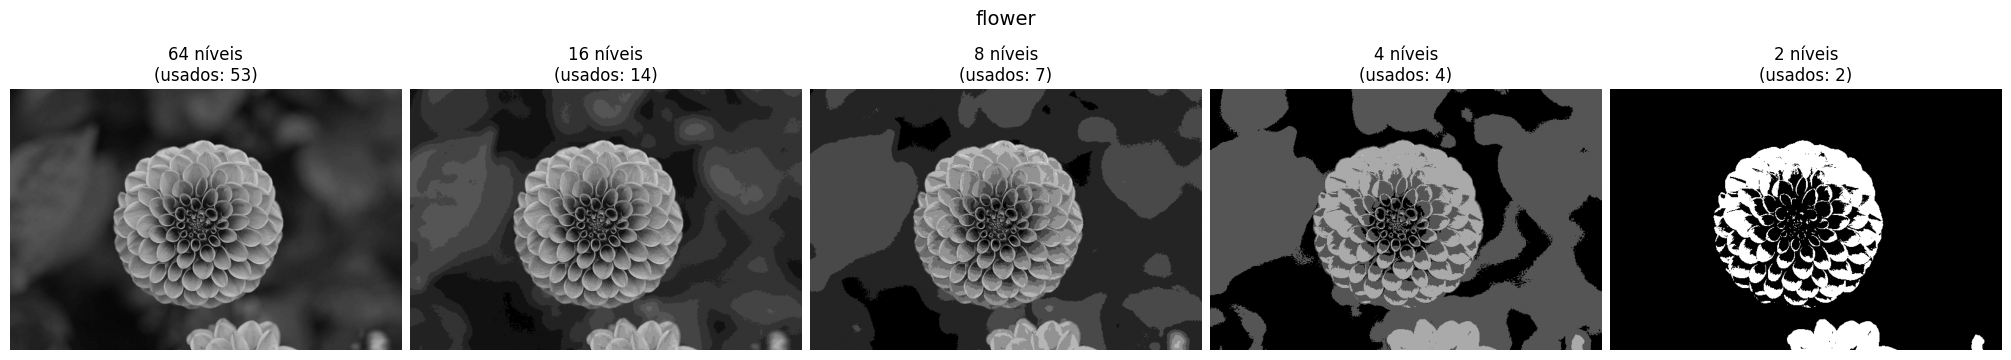

In [ ]:
img = datasets.load_sample_image("flower.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plot_quantization_grid(gray, levels_list=(64,16,8,4,2), title_prefix=Path("flower").name)

* **64 Níveis:** A imagem ainda parece natural a olho nu. O olho humano tem dificuldade de distinguir 64 tons de cinza de 256 em uma visualização rápida.

* **16 e 8 Níveis:** Aqui você começa a ver o efeito de **Posterização**. As pétalas da flor não têm mais um degradê suave; elas parecem "pintadas" com áreas de cor sólida bem definidas.

* **4 Níveis:** A imagem torna-se muito abstrata. Você perde quase toda a textura das pétalas, sobrando apenas formas geométricas de brilho.

* **2 Níveis:** É o que chamamos de **Binarização** ou **Limiarização** (**Thresholding**). A imagem agora é composta estritamente por pixels pretos ou brancos.

**Observação:** Note que nos títulos da sua imagem, o número de níveis **usados** é sempre um pouco menor que o solicitado (ex: pediu 64, usou 53). Isso acontece porque a imagem original da flor pode não conter pixels em todas as faixas de brilho possíveis, ou o arredondamento agrupou tons muito próximos.

# **Análise de Canais de Cores - RGB**

In [ ]:
rgb = datasets.load_sample_image("flower.jpg")

print("Shape:", rgb.shape)
print("Tipo:", rgb.dtype)
print("Faixa:", rgb.min(), "-", rgb.max())

Shape: (427, 640, 3)
Tipo: uint8
Faixa: 0 - 255


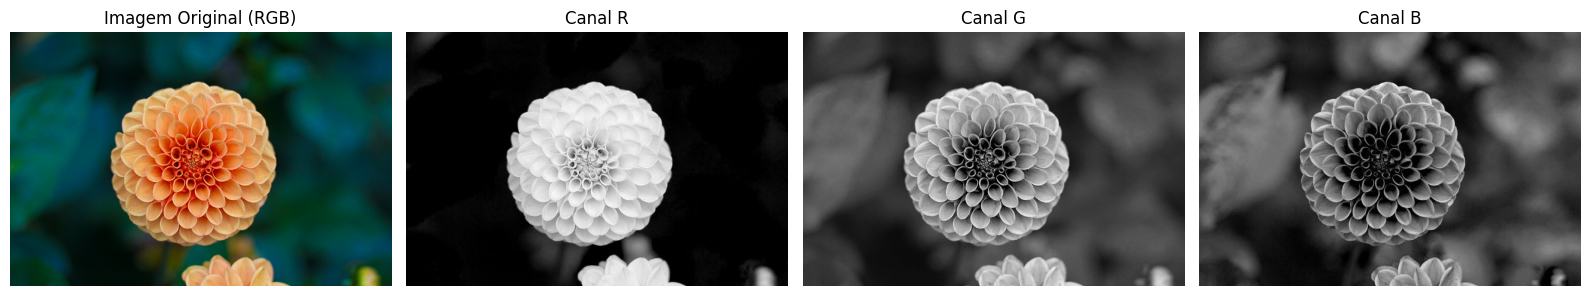

In [ ]:
# Separar os canais
R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]

# Vizualização
plt.figure(figsize=(16,6))

# (Linhas, Colunas, Posição)
plt.subplot(1,4,1)
plt.imshow(rgb)
plt.title("Imagem Original (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(R, cmap="gray")
plt.title("Canal R")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(G, cmap="gray")
plt.title("Canal G")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(B, cmap="gray")
plt.title("Canal B")
plt.axis("off")

plt.tight_layout()
plt.show()

* **Matrizes de Intensidade:** Com o isolamento do **Canal R** e o uso do **`cmap="gray"`**, os pixels brancos representam a intensidade máxima de vermelho, e os pretos a ausência total dele. Não vemos **"vermelho"** na tela nesse subplot, mas sim a **"quantidade"** de vermelho que será misturada depois.

* **A Flor no Canal R:** As pétalas da flor no **Canal R** aparecem muito claras (quase brancas), enquanto no **Canal B** elas aparecem escuras. Isso prova que a cor da flor é composta majoritariamente por tons de vermelho.

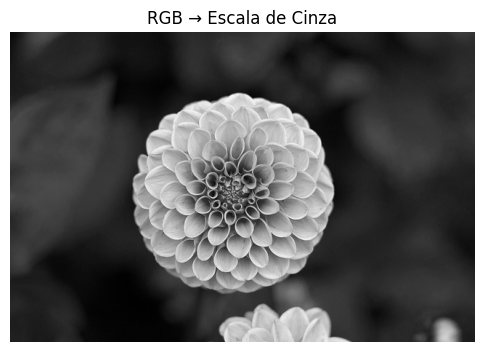

In [ ]:
gray_from_rgb = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(gray_from_rgb, cmap="gray")
plt.title("RGB → Escala de Cinza")
plt.axis("off")
plt.show()


# **Análise de Canais - HSV**

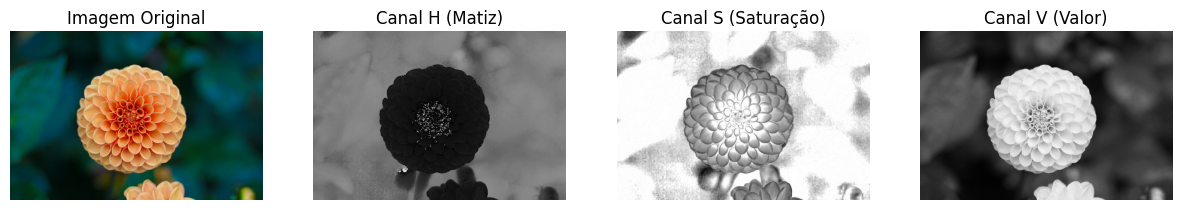

In [ ]:
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

# Separar os canais
h, s, v = cv2.split(hsv)

# Visualização do H
h_vis = np.uint8(h.astype(np.float32) * (255.0 / 179.0))

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(rgb, cmap="gray")
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(h_vis, cmap="gray")
plt.title("Canal H (Matiz)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(s, cmap="gray")
plt.title("Canal S (Saturação)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(v, cmap="gray")
plt.title("Canal V (Valor)")
plt.axis("off")

plt.show()

**Por que usar HSV em vez de RGB?**
* **Segmentação de Cores:** No RGB, se uma sombra cair sobre uma pétala vermelha, os valores de R, G e B mudam drasticamente. No HSV, a cor (Matiz/H) permanece quase a mesma, mudando apenas o Brilho (V). Isso torna o HSV perfeito para isolar objetos por cor.
* **Canal H (Hue):** Pense nele como um círculo de cores de $0^\circ$ a $360^\circ$ (mapeado para 0-179 no OpenCV). Cada número representa uma cor pura.
* **Canal S (Saturation):** Uma flor vibrante terá valores altos (branco no mapa de cinza), enquanto o asfalto ou fundo desfocado terá valores baixos (preto/cinza).